In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yadgauri","key":"6415cec59a6b9a4355ad1b40ec579f9a"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import os

for root, dirs, files in os.walk("chest_xray"):
    print(root, len(files))

chest_xray 0
chest_xray/chest_xray 1
chest_xray/chest_xray/test 1
chest_xray/chest_xray/test/NORMAL 234
chest_xray/chest_xray/test/PNEUMONIA 390
chest_xray/chest_xray/val 1
chest_xray/chest_xray/val/NORMAL 9
chest_xray/chest_xray/val/PNEUMONIA 9
chest_xray/chest_xray/train 1
chest_xray/chest_xray/train/NORMAL 1342
chest_xray/chest_xray/train/PNEUMONIA 3876
chest_xray/__MACOSX 1
chest_xray/__MACOSX/chest_xray 3
chest_xray/__MACOSX/chest_xray/test 3
chest_xray/__MACOSX/chest_xray/test/NORMAL 234
chest_xray/__MACOSX/chest_xray/test/PNEUMONIA 390
chest_xray/__MACOSX/chest_xray/val 1
chest_xray/__MACOSX/chest_xray/val/NORMAL 9
chest_xray/__MACOSX/chest_xray/val/PNEUMONIA 9
chest_xray/__MACOSX/chest_xray/train 3
chest_xray/__MACOSX/chest_xray/train/NORMAL 1342
chest_xray/__MACOSX/chest_xray/train/PNEUMONIA 3876
chest_xray/test 0
chest_xray/test/NORMAL 234
chest_xray/test/PNEUMONIA 390
chest_xray/val 0
chest_xray/val/NORMAL 8
chest_xray/val/PNEUMONIA 8
chest_xray/train 0
chest_xray/train/NORM

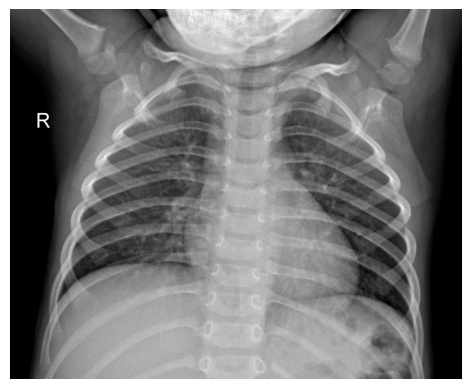

In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

image_path = glob.glob(
    "chest_xray/train/NORMAL/*.jpeg"
)[0]

img = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import os

base_dir = "chest_xray/train"
total_images = 0

for class_name in os.listdir(base_dir):

    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):

        num_images = len(os.listdir(class_path))
        total_images += num_images
        print(f"{class_name}: {num_images}")


print("Total: ", total_images)

NORMAL: 1341
PNEUMONIA: 3875
Total:  5216


In [ ]:
import pandas as pd

class_counts = {}

for class_name in os.listdir(base_dir):

    class_path = os.path.join(base_dir,class_name)

    if os.path.isdir(class_path):

        class_counts[class_name] = len(
            os.listdir(class_path)
        )

df = pd.DataFrame(
    list(class_counts.items()),
    columns=['Class','Count']
)

print(df)

       Class  Count
0     NORMAL   1341
1  PNEUMONIA   3875


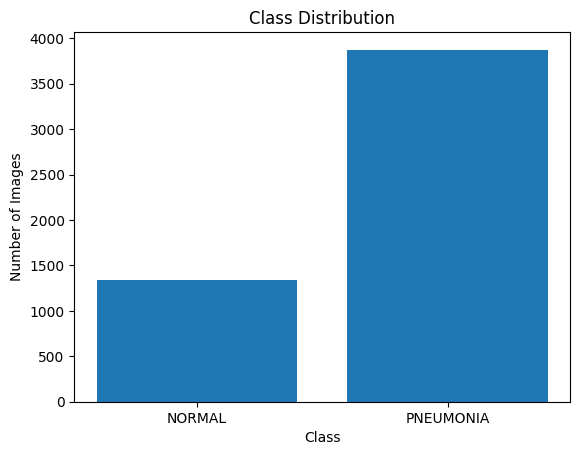

In [ ]:
import matplotlib.pyplot as plt

plt.bar(
    df['Class'],
    df['Count']
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
import cv2
import glob

heights = []
widths = []
heights1 = []
widths1 = []
heights2 = []
widths2 = []

for img_path in glob.glob(
    "chest_xray/train/*/*.jpeg"
):

    img = cv2.imread(img_path)

    h,w = img.shape[:2]

    heights.append(h)
    widths.append(w)

print("Min Height:", min(heights))
print("Max Height:", max(heights))

print("Min Width:", min(widths))
print("Max Width:", max(widths))

for img_path in glob.glob(
    "chest_xray/train/NORMAL/*.jpeg"
):

  img = cv2.imread(img_path)
  h,w = img.shape[:2]
  heights1.append(h)
  widths1.append(w)

print("NORMAL")
print("Min Height:", min(heights1))
print("Max Height:", max(heights1))

print("Min Width:", min(widths1))
print("Max Width:", max(widths1))

for img_path in glob.glob(
    "chest_xray/train/PNEUMONIA/*.jpeg"
):

  img = cv2.imread(img_path)
  h,w = img.shape[:2]
  heights2.append(h)
  widths2.append(w)
print("PNEUMONIA")
print("Min Height:", min(heights2))
print("Max Height:", max(heights2))

print("Min Width:", min(widths2))
print("Max Width:", max(widths2))

Min Height: 127
Max Height: 2663
Min Width: 384
Max Width: 2916
NORMAL
Min Height: 672
Max Height: 2663
Min Width: 912
Max Width: 2916
PNEUMONIA
Min Height: 127
Max Height: 2304
Min Width: 384
Max Width: 2772


In [ ]:
import numpy as np

print("Average Height:",
      np.mean(heights))

print("Average Width:",
      np.mean(widths))

Average Height: 968.0747699386503
Average Width: 1320.6108128834355


In [ ]:
import cv2
import numpy as np
import glob

variances = []

files = glob.glob(
    "chest_xray/train/*/*.jpeg"
)

for i in files:

  img = cv2.imread(
      i,
      cv2.IMREAD_GRAYSCALE
  )

  lap_var = cv2.Laplacian(
      img,
      cv2.CV_64F
  ).var()
  variances.append(lap_var)
print("Average variance:", np.mean(variances))
print("Min variance:", np.min(variances))
print("Max variance:", np.max(variances))

Average variance: 144.01222818269719
Min variance: 8.124156021768865
Max variance: 2505.9830384109405


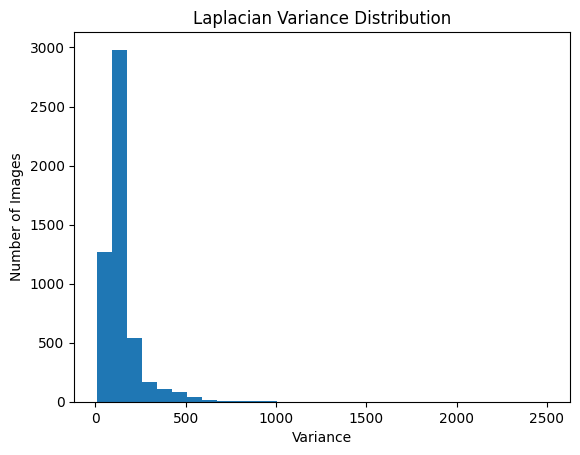

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    variances,
    bins=30
)

plt.title(
    "Laplacian Variance Distribution"
)

plt.xlabel(
    "Variance"
)

plt.ylabel(
    "Number of Images"
)

plt.show()